# Phase 1 — Exploration des Données

**Objectif :** Construire un dataset unifié, comprendre les données, identifier les problèmes de qualité.

**Sources :** 15 fichiers CSV journaliers dans `data/` — OHLCV multi-actifs + indicateurs BTC on-chain + sentiment.

**Cible :** `label_dir_1d` = 1 si `close_btc[t+1] > close_btc[t]`, sinon 0.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("data")

## 1. Chargement des sources

In [2]:
def load_ohlcv(filename, suffix):
    df = pd.read_csv(DATA_DIR / filename, parse_dates=["Date"])
    df = df.rename(columns={
        "Date": "date",
        "Open":   f"open_{suffix}",
        "High":   f"high_{suffix}",
        "Low":    f"low_{suffix}",
        "Close":  f"close_{suffix}",
        "Volume": f"volume_{suffix}",
    })
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    return df.set_index("date")

def load_single(filename, col_name):
    """Charge un CSV Date,Value et renomme la colonne Value."""
    df = pd.read_csv(DATA_DIR / filename, parse_dates=["Date"])
    df = df.rename(columns={"Date": "date", "Value": col_name})
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    return df.set_index("date")

# --- OHLCV ---
btc    = load_ohlcv("btc_daily.csv",    "btc")
xau    = load_ohlcv("xau_daily.csv",    "gold")
eth    = load_ohlcv("eth_daily.csv",    "eth")
snp    = load_ohlcv("snp500_daily.csv", "sp500")
dxy    = load_ohlcv("dxy_daily.csv",    "dxy")
vix    = load_ohlcv("vix_daily.csv",    "vix")
us10y  = load_ohlcv("us10y_daily.csv",  "us10y")
oil    = load_ohlcv("oil_daily.csv",    "oil")
silver = load_ohlcv("silver_daily.csv", "silver")

# --- Date,Value ---
fedfunds    = load_single("fedfunds_daily.csv",         "fedfunds")
funding     = load_single("btc_funding_rate_daily.csv", "funding_rate")
hashrate    = load_single("btc_hashrate_daily.csv",     "hashrate")
mvrv        = load_single("btc_mvrv_daily.csv",         "mvrv")
nupl        = load_single("btc_nupl_daily.csv",         "nupl")
gtrends     = load_single("google_trends_bitcoin.csv",  "google_trends")

print("Sources chargées :")
for name, df in [("BTC", btc), ("Gold", xau), ("ETH", eth), ("S&P500", snp),
                 ("DXY", dxy), ("VIX", vix), ("US10Y", us10y), ("Oil", oil),
                 ("Silver", silver), ("FedFunds", fedfunds), ("Funding", funding),
                 ("Hashrate", hashrate), ("MVRV", mvrv), ("NUPL", nupl),
                 ("Google Trends", gtrends)]:
    print(f"  {name:<15} {len(df):>5} lignes   {df.index.min().date()} → {df.index.max().date()}")

Sources chargées :
  BTC              5205 lignes   2012-01-01 → 2026-04-01
  Gold             3651 lignes   2012-01-03 → 2026-04-01
  ETH              3066 lignes   2017-11-09 → 2026-04-01
  S&P500           3581 lignes   2012-01-03 → 2026-03-31
  DXY              3583 lignes   2012-01-03 → 2026-04-01
  VIX              3582 lignes   2012-01-03 → 2026-04-01
  US10Y            3581 lignes   2012-01-03 → 2026-04-01
  Oil              3582 lignes   2012-01-03 → 2026-04-01
  Silver           3581 lignes   2012-01-03 → 2026-04-01
  FedFunds         5203 lignes   2012-01-01 → 2026-03-30
  Funding          2395 lignes   2019-09-10 → 2026-03-31
  Hashrate         5201 lignes   2012-01-01 → 2026-03-31
  MVRV             5736 lignes   2010-07-18 → 2026-03-31
  NUPL             5736 lignes   2010-07-18 → 2026-03-31
  Google Trends     172 lignes   2012-01-01 → 2026-04-01


## 2. Fusion sur la date (left join sur BTC)

In [3]:
df = btc.copy()
for other in [xau, eth, snp, dxy, vix, us10y, oil, silver,
              fedfunds, funding, hashrate, mvrv, nupl, gtrends]:
    df = df.join(other, how="left")

df = df.sort_index()

print(f"Dataset fusionné : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Période : {df.index.min().date()} → {df.index.max().date()}")


df.head(3)

Dataset fusionné : 5205 lignes × 51 colonnes
Période : 2012-01-01 → 2026-04-01


,open_btc,high_btc,low_btc,close_btc,volume_btc,open_gold,high_gold,low_gold,close_gold,volume_gold,open_eth,high_eth,low_eth,close_eth,volume_eth,open_sp500,high_sp500,low_sp500,close_sp500,volume_sp500,open_dxy,high_dxy,low_dxy,close_dxy,volume_dxy,...,high_vix,low_vix,close_vix,volume_vix,open_us10y,high_us10y,low_us10y,close_us10y,volume_us10y,open_oil,high_oil,low_oil,close_oil,volume_oil,open_silver,high_silver,low_silver,close_silver,volume_silver,fedfunds,funding_rate,hashrate,mvrv,nupl,google_trends
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012-01-01,4.5800,4.8400,4.5800,4.8400,10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0400,NaN,8.5914,1.0762,0.0708,0.0000
2012-01-02,4.8400,5.0000,4.8400,5.0000,10.1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0400,NaN,8.7644,1.0593,0.0560,NaN
2012-01-03,5.0000,5.3200,5.0000,5.2900,107.0853,1567.3700,1607.2700,1566.0700,1603.1300,51029.0000,NaN,NaN,NaN,NaN,NaN,1258.8600,1284.6200,1258.8600,1277.0601,3943710000.0000,80.2300,80.3900,79.5100,79.6100,0.0000,...,23.1000,22.5400,22.9700,0.0000,1.9510,1.9650,1.9140,1.9600,0.0000,99.7000,103.1800,99.6500,102.9600,275481.0000,28.1650,29.6300,28.1100,29.5330,137.0000,0.0700,NaN,9.3410,0.9906,-0.0094,NaN


In [4]:

# Moyenne mobile sur 50 jours
df["sma_50_btc"] = df["close_btc"].rolling(window=50).mean()

# Moyenne mobile sur 200 jours
df["sma_200_btc"] = df["close_btc"].rolling(window=200).mean()

# Écart-type du prix sur les 30 derniers jours
df["std_30d_btc"] = df["close_btc"].rolling(window=30).std()

# Ecart-type sur les rendements
df["return_btc"] = df["close_btc"].pct_change() # Rendement quotidien
df["volatility_30d_btc"] = df["return_btc"].rolling(window=30).std()
df.head(3)

,open_btc,high_btc,low_btc,close_btc,volume_btc,open_gold,high_gold,low_gold,close_gold,volume_gold,open_eth,high_eth,low_eth,close_eth,volume_eth,open_sp500,high_sp500,low_sp500,close_sp500,volume_sp500,open_dxy,high_dxy,low_dxy,close_dxy,volume_dxy,...,high_us10y,low_us10y,close_us10y,volume_us10y,open_oil,high_oil,low_oil,close_oil,volume_oil,open_silver,high_silver,low_silver,close_silver,volume_silver,fedfunds,funding_rate,hashrate,mvrv,nupl,google_trends,sma_50_btc,sma_200_btc,std_30d_btc,return_btc,volatility_30d_btc
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012-01-01,4.5800,4.8400,4.5800,4.8400,10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0400,NaN,8.5914,1.0762,0.0708,0.0000,NaN,NaN,NaN,NaN,NaN
2012-01-02,4.8400,5.0000,4.8400,5.0000,10.1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0400,NaN,8.7644,1.0593,0.0560,NaN,NaN,NaN,NaN,0.0331,NaN
2012-01-03,5.0000,5.3200,5.0000,5.2900,107.0853,1567.3700,1607.2700,1566.0700,1603.1300,51029.0000,NaN,NaN,NaN,NaN,NaN,1258.8600,1284.6200,1258.8600,1277.0601,3943710000.0000,80.2300,80.3900,79.5100,79.6100,0.0000,...,1.9650,1.9140,1.9600,0.0000,99.7000,103.1800,99.6500,102.9600,275481.0000,28.1650,29.6300,28.1100,29.5330,137.0000,0.0700,NaN,9.3410,0.9906,-0.0094,NaN,NaN,NaN,NaN,0.0580,NaN


## 3. Inspection générale

In [5]:
print("Types")
print(df.dtypes.to_string())
print(f"\nStatistiques descriptives")
df.describe().T[["count", "mean", "std", "min", "max"]]

Types
open_btc              float64
high_btc              float64
low_btc               float64
close_btc             float64
volume_btc            float64
open_gold             float64
high_gold             float64
low_gold              float64
close_gold            float64
volume_gold           float64
open_eth              float64
high_eth              float64
low_eth               float64
close_eth             float64
volume_eth            float64
open_sp500            float64
high_sp500            float64
low_sp500             float64
close_sp500           float64
volume_sp500          float64
open_dxy              float64
high_dxy              float64
low_dxy               float64
close_dxy             float64
volume_dxy            float64
open_vix              float64
high_vix              float64
low_vix               float64
close_vix             float64
volume_vix            float64
open_us10y            float64
high_us10y            float64
low_us10y             float64
clos

,count,mean,std,min,max
open_btc,5205.0000,22619.1661,30912.6893,4.3800,124728.0000
high_btc,5205.0000,23101.5452,31457.0585,4.3800,126272.0000
low_btc,5205.0000,22108.8578,30325.3518,3.8000,123148.0000
close_btc,5205.0000,22632.4484,30917.9697,4.3800,124728.0000
volume_btc,5205.0000,97413690.3578,1935493956.6183,0.0000,51508669357.0000
open_gold,3651.0000,1742.5801,714.5849,1050.9200,5415.7002
high_gold,3651.0000,1755.0114,722.0793,1063.4600,5586.2002
low_gold,3651.0000,1729.7694,705.8467,1046.2300,5301.6001
close_gold,3651.0000,1742.6955,714.2073,1051.5500,5318.3999
volume_gold,3651.0000,118189.0800,110846.5602,34.0000,1401078.0000


## 4. Création de la variable cible `label_dir_1d`

`label_dir_1d = 1` si le prix de clôture BTC du lendemain est supérieur à celui d'aujourd'hui, sinon `0`.

**Important :** la dernière ligne est supprimée (target inconnue) et la cible ne doit jamais apparaître comme feature.

In [6]:
df["label_dir_1d"] = (df["close_btc"].shift(-1) > df["close_btc"]).astype(int)

df = df.iloc[:-1]

print(f"Dataset après création de la cible : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Période : {df.index.min().date()} → {df.index.max().date()}")
print(f"\nDistribution de label_dir_1d :")
print(df["label_dir_1d"].value_counts())
print(f"\nTaux de hausse : {df['label_dir_1d'].mean():.2%}")

Dataset après création de la cible : 5204 lignes × 57 colonnes
Période : 2012-01-01 → 2026-03-31

Distribution de label_dir_1d :
label_dir_1d
1    2766
0    2438
Name: count, dtype: int64

Taux de hausse : 53.15%


## 5. Analyse des données manquantes

Colonnes avec valeurs manquantes (49/57) :

                    missing     pct
google_trends          5033 96.7100
funding_rate           2809 53.9800
open_eth               2139 41.1000
high_eth               2139 41.1000
low_eth                2139 41.1000
close_eth              2139 41.1000
volume_eth             2139 41.1000
high_silver            1624 31.2100
volume_us10y           1624 31.2100
open_us10y             1624 31.2100
high_us10y             1624 31.2100
low_us10y              1624 31.2100
low_silver             1624 31.2100
close_us10y            1624 31.2100
close_silver           1624 31.2100
open_silver            1624 31.2100
volume_silver          1624 31.2100
open_oil               1623 31.1900
high_oil               1623 31.1900
low_oil                1623 31.1900
close_oil              1623 31.1900
close_vix              1623 31.1900
volume_oil             1623 31.1900
volume_vix             1623 31.1900
low_vix                1623 31.1900
high_vix            

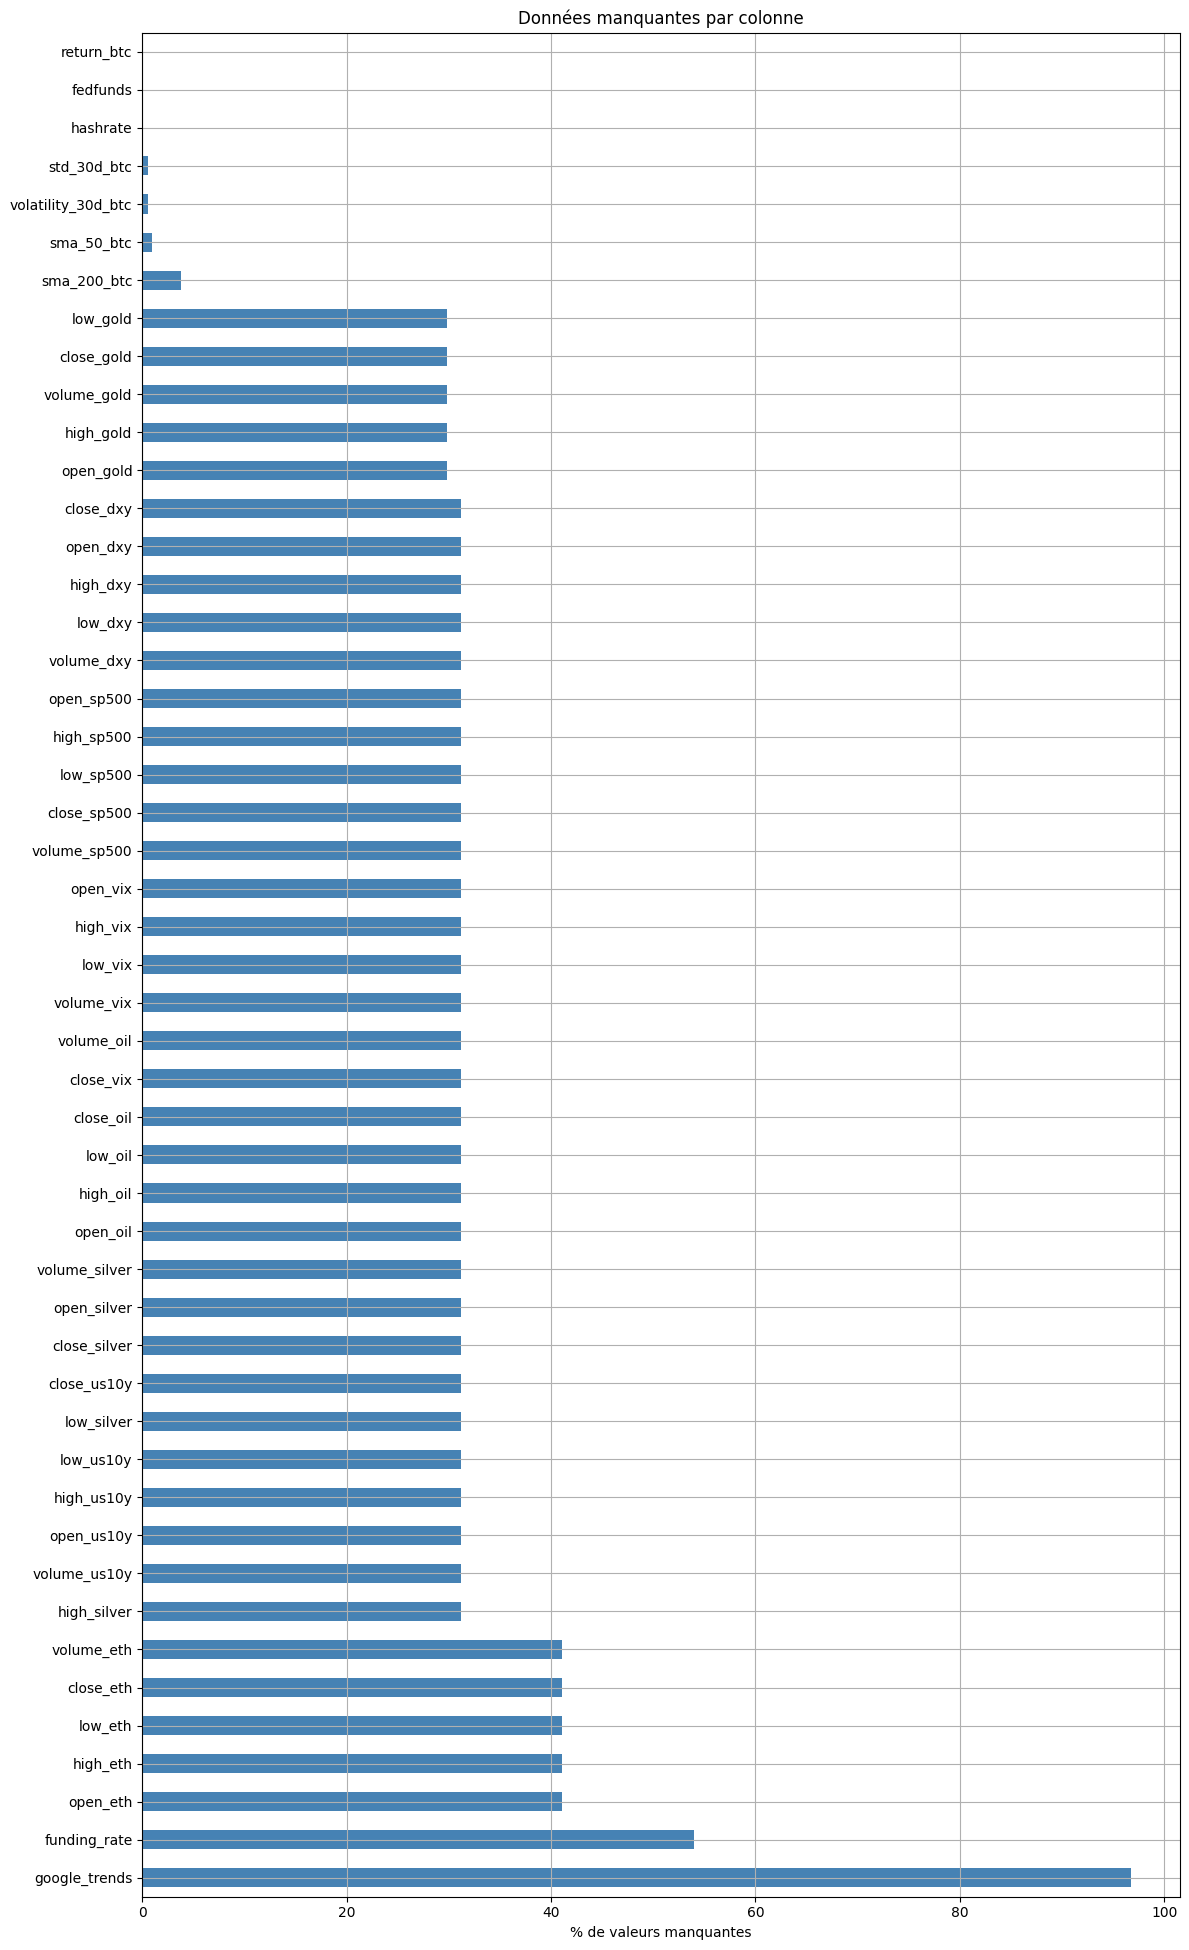

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["missing"] > 0].sort_values("pct", ascending=False)

print(f"Colonnes avec valeurs manquantes ({len(missing_df)}/{df.shape[1]}) :\n")
print(missing_df.to_string())

# Visualisation
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(missing_df) * 0.4)))
    missing_df["pct"].plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("% de valeurs manquantes")
    ax.set_title("Données manquantes par colonne")
    plt.tight_layout()
    plt.show()

## 6. Stratégie de gestion des NaN

- **Actifs marchés fermés** (gold, silver, oil, sp500, dxy, vix, us10y, fedfunds) : `forward-fill` — le dernier prix connu est propagé sur le week-end/jour férié.
- **ETH** : données depuis 2017 — NaN avant 2017 laissés tels quels (exclus du preprocessing via `dropna`).
- **Funding rate** : données depuis sept. 2019 — idem.
- **Google Trends** : mensuel → forward-fill vers quotidien.
- **Hashrate, MVRV, NUPL** : données quotidiennes depuis 2012, NaN résiduels rares → forward-fill.

In [8]:
# Colonnes à forward-fill (marchés fermés + google trends mensuel + on-chain)
ffill_cols = [c for c in df.columns if any(c.endswith(s) for s in [
    "_gold", "_sp500", "_dxy", "_vix", "_us10y", "_oil", "_silver"
])] + ["fedfunds", "google_trends", "hashrate", "mvrv", "nupl"]

df[ffill_cols] = df[ffill_cols].ffill()

# Vérification post-ffill
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]
print("NaN restants après forward-fill :")
print(missing_after.to_string() if len(missing_after) > 0 else "  Aucun (hors ETH pré-2017 et funding pré-2019)")

NaN restants après forward-fill :
open_gold                2
high_gold                2
low_gold                 2
close_gold               2
volume_gold              2
open_eth              2139
high_eth              2139
low_eth               2139
close_eth             2139
volume_eth            2139
open_sp500               2
high_sp500               2
low_sp500                2
close_sp500              2
volume_sp500             2
open_dxy                 2
high_dxy                 2
low_dxy                  2
close_dxy                2
volume_dxy               2
open_vix                 2
high_vix                 2
low_vix                  2
close_vix                2
volume_vix               2
open_us10y               2
high_us10y               2
low_us10y                2
close_us10y              2
volume_us10y             2
open_oil                 2
high_oil                 2
low_oil                  2
close_oil                2
volume_oil               2
open_silver          

## 7. Détection des outliers (IQR)

In [9]:
# Calcul sur les rendements journaliers (plus stables que les prix bruts)
close_cols = [c for c in df.columns if c.startswith("close_")]
returns = df[close_cols].pct_change().dropna()

outlier_summary = []
for col in close_cols:
    r = returns[col].dropna()
    q1, q3 = r.quantile(0.25), r.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 3 * iqr, q3 + 3 * iqr
    n_out = ((r < lower) | (r > upper)).sum()
    outlier_summary.append({
        "colonne": col,
        "n_outliers": n_out,
        "pct": round(n_out / len(r) * 100, 2),
        "min_return_%": round(r.min() * 100, 2),
        "max_return_%": round(r.max() * 100, 2),
    })

out_df = pd.DataFrame(outlier_summary).set_index("colonne")
print("Outliers sur les rendements journaliers (seuil 3×IQR) :")
print(out_df.to_string())
print("\nNote : Les outliers sont conservés — ils correspondent à des événements")
print("de marché réels (crashs, rallyes). RobustScaler en Phase 2 les atténuera.")

Outliers sur les rendements journaliers (seuil 3×IQR) :
              n_outliers    pct  min_return_%  max_return_%
colonne                                                    
close_btc             57 1.8600      -22.9500       22.5100
close_gold           148 4.8300      -11.3700       15.5100
close_eth             43 1.4000      -42.3500       26.4600
close_sp500          192 6.2700      -11.9800        9.5200
close_dxy            101 3.3000       -2.1200        1.6500
close_vix            168 5.4800      -35.7500      115.6000
close_us10y          157 5.1200      -29.3200       49.9000
close_oil            137 4.4700     -305.9700       37.6600
close_silver         213 6.9500      -31.3500       14.0300

Note : Les outliers sont conservés — ils correspondent à des événements
de marché réels (crashs, rallyes). RobustScaler en Phase 2 les atténuera.


## 8. Visualisations

### 8.1 Prix BTC dans le temps

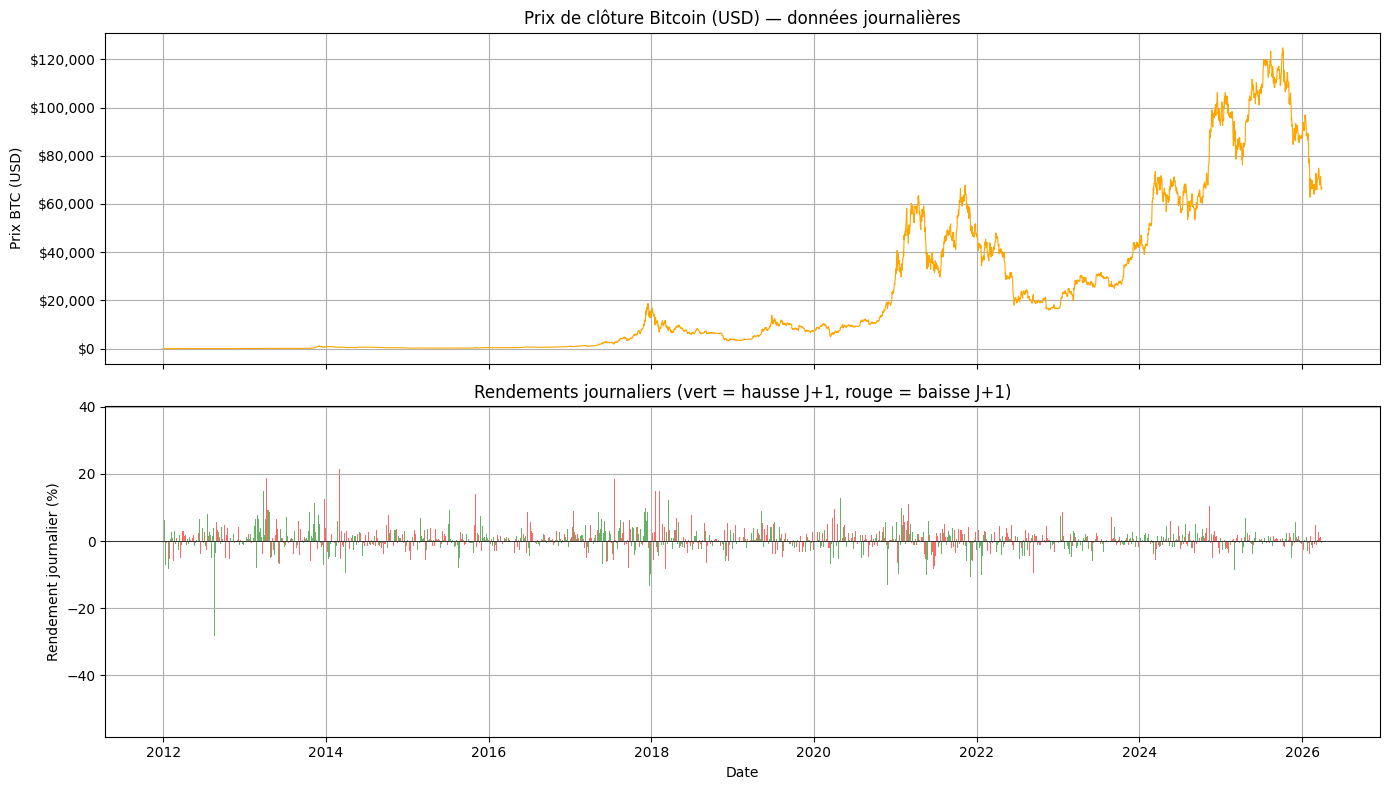

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Prix BTC
axes[0].plot(df.index, df["close_btc"], color="orange", linewidth=0.8)
axes[0].set_ylabel("Prix BTC (USD)")
axes[0].set_title("Prix de clôture Bitcoin (USD) — données journalières")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Colorer selon la cible
colors = df["label_dir_1d"].map({1: "green", 0: "red"})
axes[1].bar(df.index, df["close_btc"].pct_change() * 100,
            color=colors, width=1, alpha=0.6)
axes[1].set_ylabel("Rendement journalier (%)")
axes[1].set_title("Rendements journaliers (vert = hausse J+1, rouge = baisse J+1)")
axes[1].set_xlabel("Date")
axes[1].axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

### 8.2 Distribution de la cible

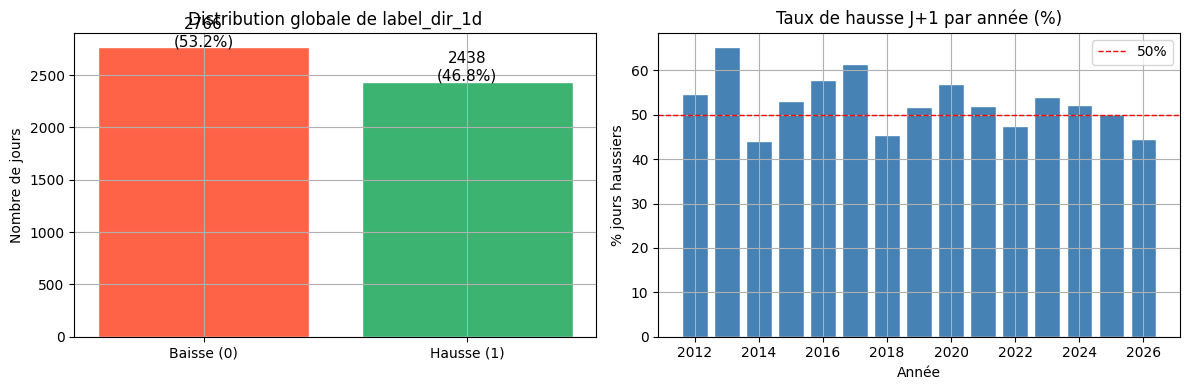

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution globale
counts = df["label_dir_1d"].value_counts()
axes[0].bar(["Baisse (0)", "Hausse (1)"], counts.values,
            color=["tomato", "mediumseagreen"], edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, f"{v}\n({v/len(df):.1%})", ha="center", fontsize=11)
axes[0].set_title("Distribution globale de label_dir_1d")
axes[0].set_ylabel("Nombre de jours")

# Distribution par année
df["year"] = df.index.year
yearly = df.groupby("year")["label_dir_1d"].mean()
axes[1].bar(yearly.index, yearly.values * 100, color="steelblue", edgecolor="white")
axes[1].axhline(50, color="red", linestyle="--", linewidth=1, label="50%")
axes[1].set_title("Taux de hausse J+1 par année (%)")
axes[1].set_ylabel("% jours haussiers")
axes[1].set_xlabel("Année")
axes[1].legend()
df.drop(columns="year", inplace=True)

plt.tight_layout()
plt.show()

### 8.3 Corrélations entre actifs (rendements journaliers)

/opt/anaconda3/envs/projetml/lib/python3.11/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


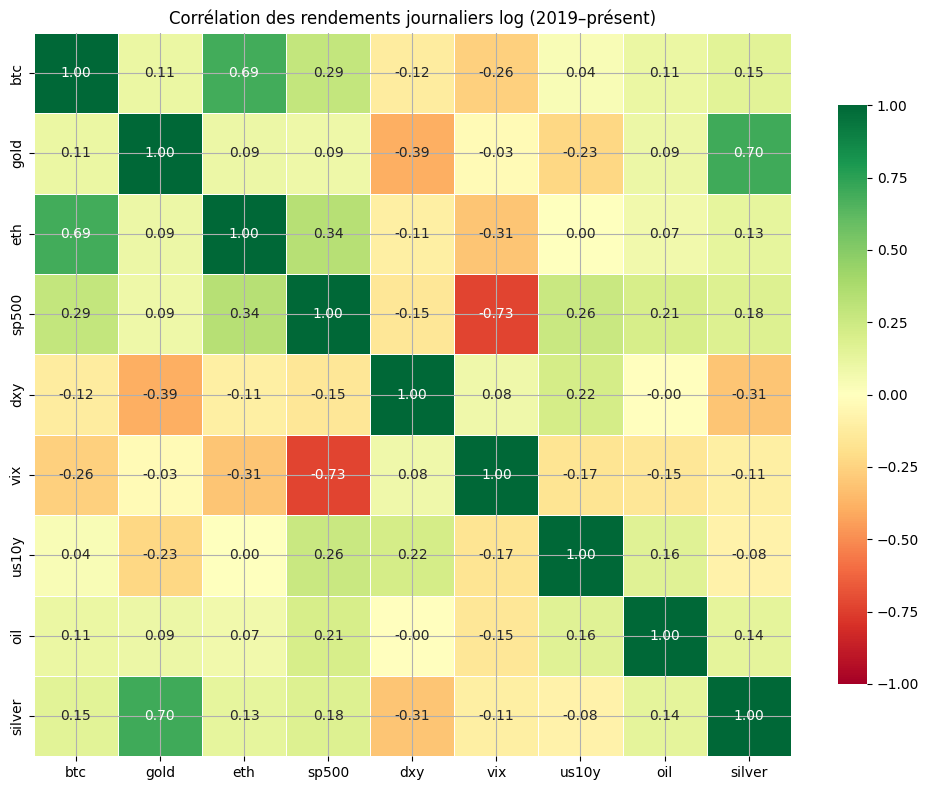

In [12]:
# Rendements log sur les prix de clôture (2019+ pour avoir tous les actifs)
close_cols = [c for c in df.columns if c.startswith("close_")]
log_ret = np.log(df[close_cols] / df[close_cols].shift(1)).dropna()
log_ret_recent = log_ret[log_ret.index >= "2019-01-01"]  # période commune à tous les actifs

# Noms courts pour l'affichage
short_names = {c: c.replace("close_", "") for c in close_cols}
corr = log_ret_recent.rename(columns=short_names).corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Corrélation des rendements journaliers log (2019–présent)")
plt.tight_layout()
plt.show()

### 8.4 Évolution des indicateurs on-chain et sentiment

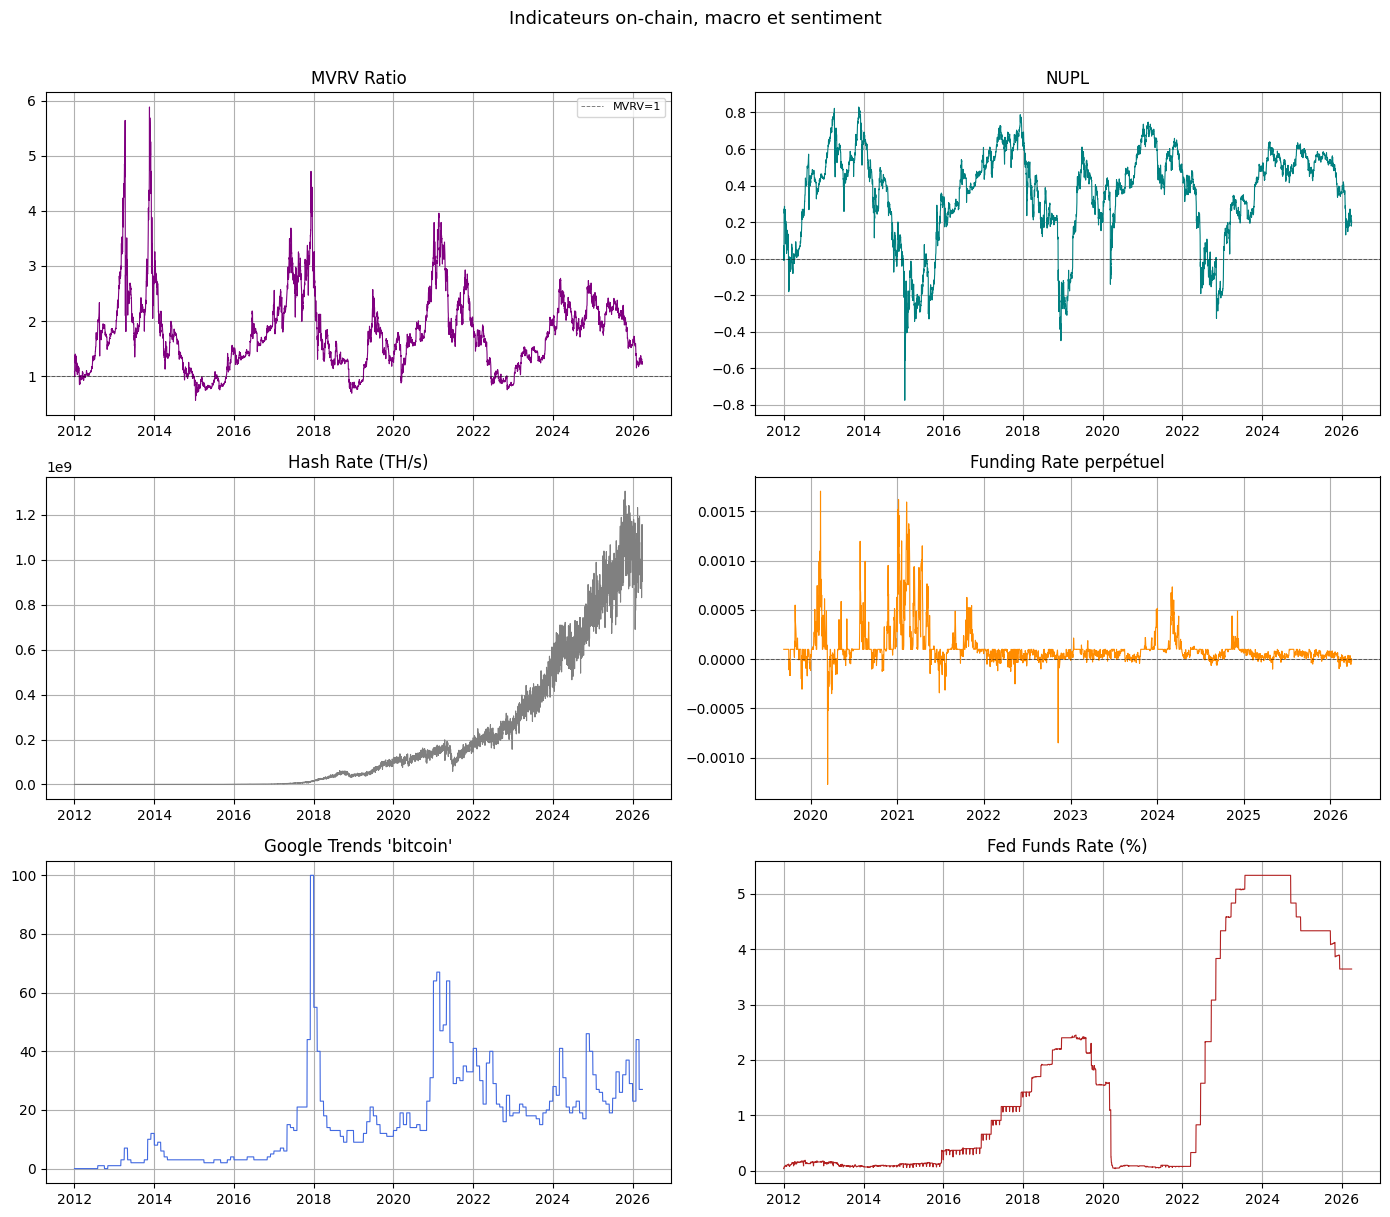

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=False)
axes = axes.flatten()

indicators = [
    ("mvrv",         "MVRV Ratio",              "purple"),
    ("nupl",         "NUPL",                    "teal"),
    ("hashrate",     "Hash Rate (TH/s)",         "gray"),
    ("funding_rate", "Funding Rate perpétuel",   "darkorange"),
    ("google_trends","Google Trends 'bitcoin'",  "royalblue"),
    ("fedfunds",     "Fed Funds Rate (%)",        "firebrick"),
]

for ax, (col, title, color) in zip(axes, indicators):
    data = df[col].dropna()
    ax.plot(data.index, data.values, color=color, linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("")
    # Ligne horizontale de référence pour certains indicateurs
    if col == "mvrv":
        ax.axhline(1, color="black", linestyle="--", linewidth=0.7, alpha=0.5, label="MVRV=1")
        ax.legend(fontsize=8)
    if col == "nupl":
        ax.axhline(0, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
    if col == "funding_rate":
        ax.axhline(0, color="black", linestyle="--", linewidth=0.7, alpha=0.5)

plt.suptitle("Indicateurs on-chain, macro et sentiment", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Sauvegarde du dataset fusionné

Ce dataset est l'input de la Phase 2 (preprocessing). Il contient toutes les colonnes brutes avant feature engineering.

In [14]:
out_path = DATA_DIR / "merged_daily.csv"
df.to_csv(out_path)
print(f"Dataset sauvegardé : {out_path}")
print(f"  Shape : {df.shape}")
print(f"  Colonnes : {list(df.columns)}")

Dataset sauvegardé : data/merged_daily.csv
  Shape : (5204, 57)
  Colonnes : ['open_btc', 'high_btc', 'low_btc', 'close_btc', 'volume_btc', 'open_gold', 'high_gold', 'low_gold', 'close_gold', 'volume_gold', 'open_eth', 'high_eth', 'low_eth', 'close_eth', 'volume_eth', 'open_sp500', 'high_sp500', 'low_sp500', 'close_sp500', 'volume_sp500', 'open_dxy', 'high_dxy', 'low_dxy', 'close_dxy', 'volume_dxy', 'open_vix', 'high_vix', 'low_vix', 'close_vix', 'volume_vix', 'open_us10y', 'high_us10y', 'low_us10y', 'close_us10y', 'volume_us10y', 'open_oil', 'high_oil', 'low_oil', 'close_oil', 'volume_oil', 'open_silver', 'high_silver', 'low_silver', 'close_silver', 'volume_silver', 'fedfunds', 'funding_rate', 'hashrate', 'mvrv', 'nupl', 'google_trends', 'sma_50_btc', 'sma_200_btc', 'std_30d_btc', 'return_btc', 'volatility_30d_btc', 'label_dir_1d']
